In [ ]:
import sqlite3
import pandas as pd
from IPython.display import display

# URLs dos arquivos CSV no GitHub
links_arquivos = {
    "tabela_ocupacao_trabalho_atualizado": "https://github.com/CamillaSemenzzatt/PROJETO-APLICADO-III/raw/main/tabela_ocupacao_trabalho_atualizado.csv",
    "tabela_posicao_categoria_atualizado": "https://github.com/CamillaSemenzzatt/PROJETO-APLICADO-III/raw/main/tabela_posicao_categoria_atualizado.csv",
    "tabela_genero_atualizado": "https://github.com/CamillaSemenzzatt/PROJETO-APLICADO-III/raw/main/tabela_genero_atualizado.csv",
    "tabela_escolaridade_atualizado": "https://github.com/CamillaSemenzzatt/PROJETO-APLICADO-III/raw/main/tabela_escolaridade_atualizado.csv",
    "tabela_posicao_atualizado": "https://github.com/CamillaSemenzzatt/PROJETO-APLICADO-III/raw/main/tabela_posicao_atualizado.csv",
    "tabela_condicao_atualizado": "https://github.com/CamillaSemenzzatt/PROJETO-APLICADO-III/raw/main/tabela_condicao_atualizado.csv",
    "tabela_idade_atualizado": "https://github.com/CamillaSemenzzatt/PROJETO-APLICADO-III/raw/main/tabela_idade_atualizado.csv",
}

tabelas = {}

# Dicionário para mapear nomes de municípios/capitais para estados
depara_municipios = {
    'Acre': 'Acre',
    'Alagoas': 'Alagoas',
    'Amapá': 'Amapá',
    'Amazonas': 'Amazonas',
    'Aracaju (SE)': 'Sergipe',
    'Bahia': 'Bahia',
    'Belo Horizonte (MG)': 'Minas Gerais',
    'Belém (PA)': 'Pará',
    'Boa Vista (RR)': 'Roraima',
    'Brasília (DF)': 'Distrito Federal',
    'Campo Grande (MS)': 'Mato Grosso do Sul',
    'Ceará': 'Ceará',
    'Cuiabá (MT)': 'Mato Grosso',
    'Curitiba (PR)': 'Paraná',
    'Distrito Federal': 'Distrito Federal',
    'Espírito Santo': 'Espírito Santo',
    'Florianópolis (SC)': 'Santa Catarina',
    'Fonte: IBGE - Pesquisa Nacional por Amostra de Domicílios Contínua trimestral': 'Fonte: IBGE - Pesquisa Nacional por Amostra de Domicílios Contínua trimestral',  # Manter a fonte como está
    'Fortaleza (CE)': 'Ceará',
    'Goiás': 'Goiás',
    'Goiânia (GO)': 'Goiás',
    'João Pessoa (PB)': 'Paraíba',
    'Macapá (AP)': 'Amapá',
    'Maceió (AL)': 'Alagoas',
    'Manaus (AM)': 'Amazonas',
    'Maranhão': 'Maranhão',
    'Mato Grosso': 'Mato Grosso',
    'Mato Grosso do Sul': 'Mato Grosso do Sul',
    'Minas Gerais': 'Minas Gerais',
    'Natal (RN)': 'Rio Grande do Norte',
    'Palmas (TO)': 'Tocantins',
    'Paraná': 'Paraná',
    'Paraíba': 'Paraíba',
    'Pará': 'Pará',
    'Pernambuco': 'Pernambuco',
    'Piauí': 'Piauí',
    'Porto Alegre (RS)': 'Rio Grande do Sul',
    'Porto Velho (RO)': 'Rondônia',
    'Recife (PE)': 'Pernambuco',
    'Rio Branco (AC)': 'Acre',
    'Rio Grande do Norte': 'Rio Grande do Norte',
    'Rio Grande do Sul': 'Rio Grande do Sul',
    'Rio de Janeiro': 'Rio de Janeiro',
    'Rio de Janeiro (RJ)': 'Rio de Janeiro',
    'Rondônia': 'Rondônia',
    'Roraima': 'Roraima',
    'Salvador (BA)': 'Bahia',
    'Santa Catarina': 'Santa Catarina',
    'Sergipe': 'Sergipe',
    'São Luís (MA)': 'Maranhão',
    'São Paulo': 'São Paulo',
    'Vitória (ES)': 'Espírito Santo',
    'São Paulo (SP)': 'São Paulo',
    'Teresina (PI)': 'Piauí'
}

# --- Leitura dos arquivos CSV e aplicação do depara ---
for nome_tabela, link in links_arquivos.items():
    try:
        # Tenta ler como CSV primeiro
        df = pd.read_csv(link)
        tabelas[nome_tabela] = df
    except pd.errors.ParserError:
        # Se der erro, tenta ler como tabela separada por tabulações
        df = pd.read_csv(link, sep='\t')
        tabelas[nome_tabela] = df

    # Aplica o depara_municipios se a coluna 'municipio' existir
    if 'municipio' in tabelas[nome_tabela].columns:
        tabelas[nome_tabela]['municipio'] = tabelas[nome_tabela]['municipio'].replace(depara_municipios)

# --- Criação do banco de dados SQLite e população das tabelas ---
db_name = "projeto_aplicado.db"
conn = sqlite3.connect(db_name)

for nome_tabela, tabela in tabelas.items():
    # Use o nome da tabela do dicionário para criar a tabela no banco de dados
    tabela.to_sql(nome_tabela, conn, if_exists='replace', index=False)
    print(f"Tabela '{nome_tabela}' criada e dados inseridos no banco de dados.")

conn.close()
print("Banco de dados populado com sucesso!")

# --- Verificação das tabelas e colunas no banco de dados (Opcional) ---
conn = sqlite3.connect(db_name)
cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tabelas_no_db = cursor.fetchall()

print("\nTabelas no banco de dados:")
for tabela in tabelas_no_db:
    nome_tabela_db = tabela[0]
    print(f"- {nome_tabela_db}")

    cursor.execute(f"PRAGMA table_info({nome_tabela_db});")
    colunas = cursor.fetchall()

    print(f"  Colunas da tabela {nome_tabela_db}:")
    for coluna in colunas:
        print(f"    - {coluna[1]}") # coluna[1] contém o nome da coluna
print("\n")

conn.close()

# --- Definição das consultas SQL ---
query_3_juncoes = """
SELECT
    o.municipio,
    o.trimestre,
    o.`Ocupação no trabalho`,
    o.`quantidade de ocupação no trabalho`,
    pc.`Posição na ocupação`,
    pc.`quantidade de posição e categoria`,
    g.Sexo,
    g.`quantidade de gênero`
FROM
    tabela_ocupacao_trabalho_atualizado o
LEFT JOIN
    tabela_posicao_categoria_atualizado pc ON o.municipio = pc.municipio AND o.trimestre = pc.trimestre
LEFT JOIN
    tabela_genero_atualizado g ON o.municipio = g.municipio AND o.trimestre = g.trimestre;
"""

query_4_juncoes = """
SELECT
    e.municipio,
    e.trimestre,
    e.`Nivel de Instrução` AS nivel_instrucao,
    e.`quantidade de escolaridade` AS quantidade_escolaridade,
    p.`posição de ocupação`,
    p.`quantidade de posição de ocupação`,
    c.`Condição de ocupação`,
    c.`quantidade de condição de ocupação`,
    i.Grupo AS grupo_etario,
    i.`quantidade de idade`
FROM
    tabela_escolaridade_atualizado e
LEFT JOIN
    tabela_posicao_atualizado p ON e.municipio = p.municipio AND e.trimestre = p.trimestre
LEFT JOIN
    tabela_condicao_atualizado c ON e.municipio = c.municipio AND e.trimestre = c.trimestre
LEFT JOIN
    tabela_idade_atualizado i ON e.municipio = i.municipio AND e.trimestre = i.trimestre;
"""

# --- Função para executar a consulta ---
def executar_consulta(query, db_name):
    conn = sqlite3.connect(db_name)
    df = pd.read_sql_query(query, conn)
    conn.close()
    return df

# --- Execução das consultas e exibição dos resultados ---
print("Executando consulta com 3 junções...")
df_3_juncoes = executar_consulta(query_3_juncoes, db_name)
print("Resultado da consulta com 3 junções:")
display(df_3_juncoes)

print("\nExecutando consulta com 4 junções...")
df_4_juncoes = executar_consulta(query_4_juncoes, db_name)
print("Resultado da consulta com 4 junções:")
display(df_4_juncoes)

print("\nProcesso concluído.")

Tabela 'tabela_ocupacao_trabalho_atualizado' criada e dados inseridos no banco de dados.
Tabela 'tabela_posicao_categoria_atualizado' criada e dados inseridos no banco de dados.
Tabela 'tabela_genero_atualizado' criada e dados inseridos no banco de dados.
Tabela 'tabela_escolaridade_atualizado' criada e dados inseridos no banco de dados.
Tabela 'tabela_posicao_atualizado' criada e dados inseridos no banco de dados.
Tabela 'tabela_condicao_atualizado' criada e dados inseridos no banco de dados.
Tabela 'tabela_idade_atualizado' criada e dados inseridos no banco de dados.
Banco de dados populado com sucesso!

Tabelas no banco de dados:
- tabela_ocupacao_trabalho_atualizado
  Colunas da tabela tabela_ocupacao_trabalho_atualizado:
    - municipio
    - trimestre
    - Ocupação no trabalho
    - quantidade de ocupação no trabalho
- tabela_posicao_categoria_atualizado
  Colunas da tabela tabela_posicao_categoria_atualizado:
    - municipio
    - trimestre
    - Posição na ocupação
    - quant

,municipio,trimestre,Ocupação no trabalho,quantidade de ocupação no trabalho,Posição na ocupação,quantidade de posição e categoria,Sexo,quantidade de gênero
0,Rondônia,1º trimestre 2012,"Agricultura, pecuária, produção florestal, pes...",149.0,Conta própria,195.0,Homens,173.0
1,Rondônia,1º trimestre 2012,"Agricultura, pecuária, produção florestal, pes...",149.0,Conta própria,195.0,Mulheres,168.0
2,Rondônia,1º trimestre 2012,"Agricultura, pecuária, produção florestal, pes...",149.0,"Empregado no setor privado, exclusive trabalha...",291.0,Homens,173.0
3,Rondônia,1º trimestre 2012,"Agricultura, pecuária, produção florestal, pes...",149.0,"Empregado no setor privado, exclusive trabalha...",291.0,Mulheres,168.0
4,Rondônia,1º trimestre 2012,"Agricultura, pecuária, produção florestal, pes...",149.0,"Empregado no setor privado, exclusive trabalha...",205.0,Homens,173.0
...,...,...,...,...,...,...,...,...
438043,Distrito Federal,4º trimestre 2024,Atividades mal definidas,0.0,Trabalhador doméstico - com carteira de trabal...,30.0,Mulheres,1377.0
438044,Distrito Federal,4º trimestre 2024,Atividades mal definidas,0.0,Trabalhador doméstico - sem carteira de trabal...,53.0,Homens,1253.0
438045,Distrito Federal,4º trimestre 2024,Atividades mal definidas,0.0,Trabalhador doméstico - sem carteira de trabal...,53.0,Mulheres,1377.0
438046,Distrito Federal,4º trimestre 2024,Atividades mal definidas,0.0,Trabalhador familiar auxiliar,7.0,Homens,1253.0



Executando consulta com 4 junções...
Resultado da consulta com 4 junções:


,municipio,trimestre,nivel_instrucao,quantidade_escolaridade,posição de ocupação,quantidade de posição de ocupação,Condição de ocupação,quantidade de condição de ocupação,grupo_etario,quantidade de idade
0,Rondônia,1º trimestre 2012,Sem instrução e menos de 1 ano de estudo,13.0,Conta própria,46.0,Fora da força de trabalho,120,14 a 17 anos,38.0
1,Rondônia,1º trimestre 2012,Sem instrução e menos de 1 ano de estudo,13.0,Conta própria,46.0,Fora da força de trabalho,120,18 a 24 anos,60.0
2,Rondônia,1º trimestre 2012,Sem instrução e menos de 1 ano de estudo,13.0,Conta própria,46.0,Fora da força de trabalho,120,25 a 39 anos,123.0
3,Rondônia,1º trimestre 2012,Sem instrução e menos de 1 ano de estudo,13.0,Conta própria,46.0,Fora da força de trabalho,120,40 a 59 anos,94.0
4,Rondônia,1º trimestre 2012,Sem instrução e menos de 1 ano de estudo,13.0,Conta própria,46.0,Fora da força de trabalho,120,60 anos ou mais,26.0
...,...,...,...,...,...,...,...,...,...,...
898395,Distrito Federal,4º trimestre 2024,Não determinado,0.0,Trabalhador familiar auxiliar,7.0,Força de trabalho - ocupada,1606,14 a 17 anos,190.0
898396,Distrito Federal,4º trimestre 2024,Não determinado,0.0,Trabalhador familiar auxiliar,7.0,Força de trabalho - ocupada,1606,18 a 24 anos,328.0
898397,Distrito Federal,4º trimestre 2024,Não determinado,0.0,Trabalhador familiar auxiliar,7.0,Força de trabalho - ocupada,1606,25 a 39 anos,805.0
898398,Distrito Federal,4º trimestre 2024,Não determinado,0.0,Trabalhador familiar auxiliar,7.0,Força de trabalho - ocupada,1606,40 a 59 anos,872.0



Processo concluído.
Tabela 'tabela_ocupacao_trabalho_atualizado' criada e dados inseridos no banco de dados.
Tabela 'tabela_posicao_categoria_atualizado' criada e dados inseridos no banco de dados.
Tabela 'tabela_genero_atualizado' criada e dados inseridos no banco de dados.
Tabela 'tabela_escolaridade_atualizado' criada e dados inseridos no banco de dados.
Tabela 'tabela_posicao_atualizado' criada e dados inseridos no banco de dados.
Tabela 'tabela_condicao_atualizado' criada e dados inseridos no banco de dados.
Tabela 'tabela_idade_atualizado' criada e dados inseridos no banco de dados.
Banco de dados populado com sucesso!

Tabelas no banco de dados:
- tabela_ocupacao_trabalho_atualizado
  Colunas da tabela tabela_ocupacao_trabalho_atualizado:
    - municipio
    - trimestre
    - Ocupação no trabalho
    - quantidade de ocupação no trabalho
- tabela_posicao_categoria_atualizado
  Colunas da tabela tabela_posicao_categoria_atualizado:
    - municipio
    - trimestre
    - Posição na

,municipio,trimestre,Ocupação no trabalho,quantidade de ocupação no trabalho,Posição na ocupação,quantidade de posição e categoria,Sexo,quantidade de gênero
0,Rondônia,1º trimestre 2012,"Agricultura, pecuária, produção florestal, pes...",149.0,Conta própria,195.0,Homens,173.0
1,Rondônia,1º trimestre 2012,"Agricultura, pecuária, produção florestal, pes...",149.0,Conta própria,195.0,Mulheres,168.0
2,Rondônia,1º trimestre 2012,"Agricultura, pecuária, produção florestal, pes...",149.0,"Empregado no setor privado, exclusive trabalha...",291.0,Homens,173.0
3,Rondônia,1º trimestre 2012,"Agricultura, pecuária, produção florestal, pes...",149.0,"Empregado no setor privado, exclusive trabalha...",291.0,Mulheres,168.0
4,Rondônia,1º trimestre 2012,"Agricultura, pecuária, produção florestal, pes...",149.0,"Empregado no setor privado, exclusive trabalha...",205.0,Homens,173.0
...,...,...,...,...,...,...,...,...
438043,Distrito Federal,4º trimestre 2024,Atividades mal definidas,0.0,Trabalhador doméstico - com carteira de trabal...,30.0,Mulheres,1377.0
438044,Distrito Federal,4º trimestre 2024,Atividades mal definidas,0.0,Trabalhador doméstico - sem carteira de trabal...,53.0,Homens,1253.0
438045,Distrito Federal,4º trimestre 2024,Atividades mal definidas,0.0,Trabalhador doméstico - sem carteira de trabal...,53.0,Mulheres,1377.0
438046,Distrito Federal,4º trimestre 2024,Atividades mal definidas,0.0,Trabalhador familiar auxiliar,7.0,Homens,1253.0



Executando consulta com 4 junções...
Resultado da consulta com 4 junções:


,municipio,trimestre,nivel_instrucao,quantidade_escolaridade,posição de ocupação,quantidade de posição de ocupação,Condição de ocupação,quantidade de condição de ocupação,grupo_etario,quantidade de idade
0,Rondônia,1º trimestre 2012,Sem instrução e menos de 1 ano de estudo,13.0,Conta própria,46.0,Fora da força de trabalho,120,14 a 17 anos,38.0
1,Rondônia,1º trimestre 2012,Sem instrução e menos de 1 ano de estudo,13.0,Conta própria,46.0,Fora da força de trabalho,120,18 a 24 anos,60.0
2,Rondônia,1º trimestre 2012,Sem instrução e menos de 1 ano de estudo,13.0,Conta própria,46.0,Fora da força de trabalho,120,25 a 39 anos,123.0
3,Rondônia,1º trimestre 2012,Sem instrução e menos de 1 ano de estudo,13.0,Conta própria,46.0,Fora da força de trabalho,120,40 a 59 anos,94.0
4,Rondônia,1º trimestre 2012,Sem instrução e menos de 1 ano de estudo,13.0,Conta própria,46.0,Fora da força de trabalho,120,60 anos ou mais,26.0
...,...,...,...,...,...,...,...,...,...,...
898395,Distrito Federal,4º trimestre 2024,Não determinado,0.0,Trabalhador familiar auxiliar,7.0,Força de trabalho - ocupada,1606,14 a 17 anos,190.0
898396,Distrito Federal,4º trimestre 2024,Não determinado,0.0,Trabalhador familiar auxiliar,7.0,Força de trabalho - ocupada,1606,18 a 24 anos,328.0
898397,Distrito Federal,4º trimestre 2024,Não determinado,0.0,Trabalhador familiar auxiliar,7.0,Força de trabalho - ocupada,1606,25 a 39 anos,805.0
898398,Distrito Federal,4º trimestre 2024,Não determinado,0.0,Trabalhador familiar auxiliar,7.0,Força de trabalho - ocupada,1606,40 a 59 anos,872.0



Processo concluído.


In [ ]:
import sqlite3
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import ipywidgets as widgets
import seaborn as sns # Importar seaborn para mapas de calor (opcional, se quiser adicionar)

# ... (seu código anterior - consultas SQL, executar_consulta, carregamento das tabelas) ...

def recomendar_programas_com_porcentagem(municipio, trimestre, df_3_juncoes, df_4_juncoes):
    """Recomenda programas sociais com base nas características do município e trimestre,
       usando duas tabelas separadas e exibe um gráfico das porcentagens."""

    dados_municipio_3 = df_3_juncoes[(df_3_juncoes["municipio"] == municipio) & (df_3_juncoes["trimestre"] == trimestre)].copy()
    dados_municipio_4 = df_4_juncoes[(df_4_juncoes["municipio"] == municipio) & (df_4_juncoes["trimestre"] == trimestre)].copy()

    if dados_municipio_3.empty and dados_municipio_4.empty:
        print(f"Nenhum dado disponível para o município: {municipio} no trimestre: {trimestre}")
        return

    print(f"\nAnálise para o município: {municipio} no trimestre: {trimestre}")

    total_pessoas = dados_municipio_4["quantidade de idade"].sum()

    if total_pessoas == 0:
        print("Não há registros suficientes para calcular porcentagens de beneficiários para programas sociais.")
        return

    recomendacoes = []
    porcentagens = {}

    # --- Recomendações e Cálculo de Porcentagens por Programa ---

    # Minha Casa Minha Vida
    if "grupo_etario" in dados_municipio_4.columns:
        beneficiarios_mcmv = dados_municipio_4.loc[dados_municipio_4["grupo_etario"] == "25 a 39 anos", "quantidade de idade"].sum()
        if beneficiarios_mcmv > 0:
            porcentagem_mcmv = (beneficiarios_mcmv / total_pessoas) * 100
            recomendacoes.append(f"- Minha Casa Minha Vida: {porcentagem_mcmv:.2f}% das pessoas estão na faixa etária beneficiada (25 a 39 anos).")
            porcentagens["Minha Casa Minha Vida"] = porcentagem_mcmv
        else:
            print("  - Minha Casa Minha Vida: Nenhum registro encontrado na faixa etária de 25 a 39 anos.")


    # Auxílio Emergencial - Cálculo ajustado para quem atende ambos os critérios (idade 18-59 E fora da força de trabalho)
    if "grupo_etario" in dados_municipio_4.columns and "Condição de ocupação" in dados_municipio_4.columns:
        condicao_idade = dados_municipio_4["grupo_etario"].isin(["18 a 24 anos", "25 a 39 anos", "40 a 59 anos"])
        condicao_ocupacao = dados_municipio_4["Condição de ocupação"].str.contains("Fora da força de trabalho", na=False)

        # Filtrar o DataFrame para pessoas que atendem ambas as condições
        beneficiarios_emergencial_df = dados_municipio_4.loc[condicao_idade & condicao_ocupacao]

        # Somar a quantidade de pessoas qualificadas
        beneficiarios_emergencial = beneficiarios_emergencial_df["quantidade de idade"].sum()

        if beneficiarios_emergencial > 0:
            porcentagem_emergencial = (beneficiarios_emergencial / total_pessoas) * 100
            recomendacoes.append(f"- Auxílio Emergencial: {porcentagem_emergencial:.2f}% das pessoas estão fora da força de trabalho e na faixa etária de 18 a 59 anos.")
            porcentagens["Auxílio Emergencial"] = porcentagem_emergencial
        else:
            print("  - Auxílio Emergencial: Nenhum registro encontrado para pessoas fora da força de trabalho e na faixa etária de 18 a 59 anos.")
    else:
        print("  - Auxílio Emergencial: Colunas 'grupo_etario' ou 'Condição de ocupação' não encontradas em df_4_juncoes.")


    # BPC (Benefício de Prestação Continuada)
    if "grupo_etario" in dados_municipio_4.columns or "Condição de ocupação" in dados_municipio_4.columns:
        beneficiarios_idosos = 0
        if "grupo_etario" in dados_municipio_4.columns:
            beneficiarios_idosos = dados_municipio_4.loc[dados_municipio_4["grupo_etario"] == "60 anos ou mais", "quantidade de idade"].sum()

        beneficiarios_deficiencia = 0
        if "Condição de ocupação" in dados_municipio_4.columns:
            # Ajuste para somar a quantidade de pessoas com deficiência se a coluna existir e for numérica
            if 'quantidade de condição de ocupação' in dados_municipio_4.columns:
                 beneficiarios_deficiencia = dados_municipio_4.loc[dados_municipio_4["Condição de ocupação"].str.contains("Pessoas com deficiência", na=False), 'quantidade de condição de ocupação'].sum()
            else:
                 # Se a coluna de quantidade específica não existir, podemos tentar estimar usando a quantidade de idade para essas linhas
                 beneficiarios_deficiencia = dados_municipio_4.loc[dados_municipio_4["Condição de ocupação"].str.contains("Pessoas com deficiência", na=False), 'quantidade de idade'].sum()


        total_beneficiarios_bpc = beneficiarios_idosos + beneficiarios_deficiencia

        if total_beneficiarios_bpc > 0:
            porcentagem_bpc = (total_beneficiarios_bpc / total_pessoas) * 100
            recomendacoes.append(f"- BPC: {porcentagem_bpc:.2f}% das pessoas são idosos ou pessoas com deficiência que podem se beneficiar.")
            porcentagens["BPC"] = porcentagem_bpc
        else:
            print("  - BPC: Nenhum registro encontrado para idosos ou pessoas com deficiência.")
    else:
        print("  - BPC: Colunas 'grupo_etario' ou 'Condição de ocupação' não encontradas em df_4_juncoes.")


    # Programas para jovens (18 a 24 anos) - Agrupando Acessuas Trabalho, Jovem Aprendiz, ID Jovem, Pronatec
    if "grupo_etario" in dados_municipio_4.columns:
        beneficiarios_jovens = dados_municipio_4.loc[dados_municipio_4["grupo_etario"] == "18 a 24 anos", "quantidade de idade"].sum()
        if beneficiarios_jovens > 0:
            porcentagem_jovens = (beneficiarios_jovens / total_pessoas) * 100
            recomendacoes.append(f"- Programas para jovens (Acessuas Trabalho, Jovem Aprendiz, ID Jovem, Pronatec): {porcentagem_jovens:.2f}% das pessoas estão na faixa etária jovem (18 a 24 anos) elegível para qualificação/oportunidades.")
            porcentagens["Programas para jovens"] = porcentagem_jovens
        else:
            print("  - Programas para jovens: Nenhum registro encontrado na faixa etária de 18 a 24 anos.")
    else:
        print("  - Programas para jovens: Coluna 'grupo_etario' não encontrada em df_4_juncoes.")


    # Brasil Alfabetizado
    if "nivel_instrucao" in dados_municipio_4.columns:
        beneficiarios_alfabetizacao = dados_municipio_4.loc[dados_municipio_4["nivel_instrucao"] == "Ensino fundamental incompleto ou equivalente", "quantidade_escolaridade"].sum()
        if beneficiarios_alfabetizacao > 0:
            porcentagem_alfabetizacao = (beneficiarios_alfabetizacao / total_pessoas) * 100
            recomendacoes.append(f"- Brasil Alfabetizado: {porcentagem_alfabetizacao:.2f}% das pessoas não completaram o ensino fundamental.")
            porcentagens["Brasil Alfabetizado"] = porcentagem_alfabetizacao
        else:
            print("  - Brasil Alfabetizado: Nenhum registro encontrado com 'Ensino fundamental incompleto ou equivalente'.")
    else:
         print("  - Brasil Alfabetizado: Coluna 'nivel_instrucao' não encontrada em df_4_juncoes.")


    # Qualifica Mais
    if "Ocupação no trabalho" in dados_municipio_3.columns:
        # Usamos .str.contains com regex=True para buscar por múltiplas strings
        condicao_qualifica = dados_municipio_3["Ocupação no trabalho"].str.contains("Trabalhadores de serviços, vendedores do comércio em lojas e mercados|Trabalhadores da produção de bens e serviços industriais", na=False, regex=True)
        beneficiarios_qualifica = dados_municipio_3.loc[condicao_qualifica, "quantidade de ocupação no trabalho"].sum()

        if beneficiarios_qualifica > 0:
             porcentagem_qualifica = (beneficiarios_qualifica / total_pessoas) * 100
             recomendacoes.append(f"- Qualifica Mais: {porcentagem_qualifica:.2f}% das pessoas trabalham em áreas que podem se qualificar.")
             porcentagens["Qualifica Mais"] = porcentagem_qualifica
        else:
             print("  - Qualifica Mais: Nenhum registro encontrado para as ocupações especificadas.")
    else:
        print("  - Qualifica Mais: Coluna 'Ocupação no trabalho' não encontrada em df_3_juncoes.")


    # --- Exibição das Recomendações e Gráfico ---

    if not recomendacoes:
        print("\nNenhum programa social recomendado com base nos dados disponíveis para este município e trimestre.")
    else:
        print("\nPotenciais Programas Sociais e Porcentagem de Beneficiários:")
        for recomendacao in recomendacoes:
            print(recomendacao)

        # Criação do gráfico de barras das porcentagens
        if porcentagens:
            programas = list(porcentagens.keys())
            percentuais = list(porcentagens.values())

            plt.figure(figsize=(14, 7)) # Ajusta o tamanho do gráfico
            plt.bar(programas, percentuais, color='#2E8B57') # Cor verde musgo
            plt.ylabel("Porcentagem de Pessoas Potencialmente Beneficiadas (%)")
            plt.title(f"Porcentagem de Pessoas Potencialmente Beneficiadas por Programa Social\n em {municipio} no {trimestre}")
            plt.xticks(rotation=45, ha='right') # Rotaciona os rótulos do eixo x para melhor visualização
            plt.ylim(0, 100) # Define o limite do eixo y de 0 a 100
            plt.grid(axis='y', linestyle='--', alpha=0.7) # Adiciona uma grade horizontal suave
            plt.tight_layout() # Ajusta o layout para evitar sobreposição
            plt.show()
        else:
            print("\nNenhum dado de porcentagem para exibir no gráfico.")


# --- Função para escolher município e trimestre com widgets (mantida do seu código) ---
def escolher_municipio_e_trimestre():
    # Assumindo que df_3_juncoes foi carregado globalmente ou passado para esta função
    if 'df_3_juncoes' not in globals():
        print("DataFrame df_3_juncoes não encontrado. Execute a célula de carregamento de dados primeiro.")
        return

    municipios_disponiveis = sorted(df_3_juncoes["municipio"].unique())
    trimestres_disponiveis = sorted(df_3_juncoes["trimestre"].unique())

    # Adiciona um valor vazio no início das opções
    municipios_disponiveis = [''] + municipios_disponiveis
    trimestres_disponiveis = [''] + trimestres_disponiveis

    municipio_widget = widgets.Dropdown(
        options=municipios_disponiveis,
        value='',  # Define o valor inicial como vazio
        description='Município:',
        disabled=False,
    )

    trimestre_widget = widgets.Dropdown(
        options=trimestres_disponiveis,
        value='',  # Define o valor inicial como vazio
        description='Trimestre:',
        disabled=False,
    )

    output_widget = widgets.Output()

    def on_change(change):
        with output_widget:
            output_widget.clear_output()  # Limpa a saída anterior
            municipio_escolhido = municipio_widget.value
            trimestre_escolhido = trimestre_widget.value

            if municipio_escolhido and trimestre_escolhido:
                print(f"Analisando dados para o município: {municipio_escolhido} e trimestre: {trimestre_escolhido}")
                # Certifique-se de que df_4_juncoes também está disponível
                if 'df_4_juncoes' in globals():
                     recomendar_programas_com_porcentagem(municipio_escolhido, trimestre_escolhido, df_3_juncoes, df_4_juncoes)
                else:
                     print("DataFrame df_4_juncoes não encontrado. Execute a célula de carregamento de dados primeiro.")
            elif municipio_escolhido or trimestre_escolhido:
                print("Por favor, selecione tanto um município quanto um trimestre.")
            else:
                print("Selecione um município e um trimestre para ver as recomendações.")


    municipio_widget.observe(on_change, names='value')
    trimestre_widget.observe(on_change, names='value')

    display(widgets.VBox([municipio_widget, trimestre_widget, output_widget]))

# Chame a função para exibir os widgets
escolher_municipio_e_trimestre()

In [ ]:
import sqlite3
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import ipywidgets as widgets
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
# Removendo GridSearchCV
from sklearn.linear_model import LogisticRegression # Mantido no import caso queira usar depois
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
# Removendo LabelEncoder (não usado no pipeline atual)
from sklearn.preprocessing import OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.exceptions import UndefinedMetricWarning
import warnings

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

# --- (Seu código anterior para carregar dados, criar DataFrames df_3_juncoes e df_4_juncoes, etc.) ---
# Certifique-se de que df_4_juncoes está carregado e disponível.

print("\n--- Treinamento de Modelo de Classificação (RandomForestClassifier) com Amostra Reduzida ---")

# 1. Definir a Tarefa, Features (X) e Target (y) - Mantido igual
target_classificacao = 'Condição de ocupação'

features_classificacao = [
    'municipio',
    'trimestre',
    'nivel_instrucao',
    'posição de ocupação',
    'grupo_etario',
    'quantidade_escolaridade',
    'quantidade de posição de ocupação',
    'quantidade de idade',
    'quantidade de condição de ocupação'
]

colunas_necessarias_classificacao = features_classificacao + [target_classificacao]

if all(col in df_4_juncoes.columns for col in colunas_necessarias_classificacao):

    df_modelo_classificacao = df_4_juncoes[colunas_necessarias_classificacao].copy()
    df_modelo_classificacao.dropna(subset=[target_classificacao], inplace=True)

    if df_modelo_classificacao.empty:
        print("DataFrame vazio após remover valores ausentes no target. Não é possível treinar o modelo.")
    else:
        X = df_modelo_classificacao.drop(target_classificacao, axis=1)
        y = df_modelo_classificacao[target_classificacao]

        # --- ADICIONANDO AMOSTRAGEM AQUI ---
        # Defina a fração dos dados originais a serem usados (ex: 0.1 para 10%)
        fracao_amostra = 0.1 # Ajuste este valor conforme necessário (ex: 0.05, 0.02)

        print(f"\nUsando uma amostra de {fracao_amostra*100:.0f}% dos dados para testes rápidos.")

        # Amostra estratificada para manter a proporção das classes no target, se possível
        try:
             X_amostra, _, y_amostra, _ = train_test_split(X, y, train_size=fracao_amostra, random_state=42, stratify=y)
             print("Amostragem estratificada realizada com sucesso.")
        except ValueError as e:
             print(f"Erro ao realizar amostragem estratificada na amostra inicial: {e}. Tentando amostragem aleatória simples...")
             # Amostragem aleatória simples se estratificação falhar (por exemplo, classes com poucas amostras)
             df_amostra = df_modelo_classificacao.sample(frac=fracao_amostra, random_state=42).copy()
             X_amostra = df_amostra.drop(target_classificacao, axis=1)
             y_amostra = df_amostra[target_classificacao]


        print(f"Tamanho da amostra total: {len(X_amostra)} amostras")
        # --- FIM DA ADIÇÃO DA AMOSTRAGEM ---


        colunas_categoricas = X_amostra.select_dtypes(include=['object', 'category']).columns.tolist()
        colunas_numericas = X_amostra.select_dtypes(include=np.number).columns.tolist()

        # 2. Pré-processar Dados usando Pipelines e ColumnTransformer - Usando a amostra
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', 'passthrough', colunas_numericas),
                ('cat', OneHotEncoder(handle_unknown='ignore'), colunas_categoricas)
            ],
            remainder='passthrough'
        )

        # 3. Dividir a Amostra em Treino e Teste
        # test_size=0.20 significa que 20% da AMOSTRA serão usados para teste
        try:
            X_treino, X_teste, y_treino, y_teste = train_test_split(X_amostra, y_amostra, test_size=0.20, random_state=42, stratify=y_amostra)
        except ValueError as e:
            print(f"Erro ao dividir a amostra de treino/teste com stratify: {e}")
            print("Isso pode ocorrer se alguma classe na amostra tiver apenas uma amostra.")
            print("Tentando dividir a amostra sem stratify...")
            X_treino, X_teste, y_treino, y_teste = train_test_split(X_amostra, y_amostra, test_size=0.20, random_state=42)


        print(f"Tamanho do conjunto de treino (amostra): {len(X_treino)} amostras")
        print(f"Tamanho do conjunto de teste (amostra): {len(X_teste)} amostras")

        # 4. Definir Pipeline para RandomForestClassifier com SMOTE

        # Pipeline com RandomForestClassifier (com SMOTE)
        pipeline_rf = ImbPipeline(steps=[
            ('preprocessor', preprocessor),
            ('smote', SMOTE(random_state=42)),
            ('classifier', RandomForestClassifier(random_state=42)) # Usando hiperparâmetros padrão ou definidos manualmente
        ])

        # 5. Treinar o Modelo (Diretamente o Pipeline)
        print("\nTreinando o Pipeline (RandomForestClassifier com SMOTE) diretamente...")
        try:
            pipeline_rf.fit(X_treino, y_treino)
            print("Fit do Pipeline concluído.")

            # --- Gerar Previsões no conjunto de teste ---
            y_pred_rf = pipeline_rf.predict(X_teste)
            print("\nPrevisões geradas para o conjunto de teste.")

            # --- Avaliar o Modelo ---
            print("\nMétricas de Avaliação no Conjunto de Teste:")

            # Acurácia
            accuracy = accuracy_score(y_teste, y_pred_rf)
            print(f"  Acurácia: {accuracy:.2f}")

            # Precisão, Revocação e F1-Score (para classificação multiclasse, usar average)
            try:
                precision = precision_score(y_teste, y_pred_rf, average='weighted')
                recall = recall_score(y_teste, y_pred_rf, average='weighted')
                f1 = f1_score(y_teste, y_pred_rf, average='weighted')

                print(f"  Precisão (Weighted): {precision:.2f}")
                print(f"  Revocação (Weighted): {recall:.2f}")
                print(f"  F1-Score (Weighted): {f1:.2f}")

                # Relatório de Classificação completo
                print("\nRelatório de Classificação:")
                print(classification_report(y_teste, y_pred_rf))

            except ValueError as e:
                 print(f"Erro ao calcular métricas de Precisão, Revocação ou F1-Score: {e}")
                 print("Isso pode ocorrer se as previsões não contiverem todas as classes presentes nos valores reais de teste.")


            # AUC-ROC (Para classificação multiclasse, requer predict_proba)
            if hasattr(pipeline_rf, 'predict_proba'):
                try:
                    y_prob_rf = pipeline_rf.predict_proba(X_teste)
                    classes_na_amostra_total = np.unique(y_amostra) # Use as classes da amostra total
                    y_teste_bin = label_binarize(y_teste, classes=classes_na_amostra_total)
                    n_classes = y_teste_bin.shape[1]

                    if n_classes > 1:
                         auc_roc = roc_auc_score(y_teste_bin, y_prob_rf, average='weighted')
                         print(f"  AUC-ROC (Weighted OvR): {auc_roc:.2f}")
                    else:
                         print("  AUC-ROC não calculado: Apenas uma classe presente nos dados de teste.")
                except Exception as e:
                     print(f"Erro ao calcular AUC-ROC: {e}")
                     print("Verifique se y_prob_rf foi gerado corretamente e se há mais de uma classe no conjunto de teste.")
            else:
                print("\nModelo não suporta predict_proba, AUC-ROC não calculado.")

        except Exception as e:
            print(f"\nErro durante o treinamento do Pipeline: {e}")
            print("O Pipeline não completou o treinamento.")


else:
    print("Algumas colunas necessárias para o modelo de classificação não foram encontradas em df_4_juncoes.")


--- Treinamento de Modelo de Classificação (RandomForestClassifier) com Amostra Reduzida ---

Usando uma amostra de 10% dos dados para testes rápidos.
Amostragem estratificada realizada com sucesso.
Tamanho da amostra total: 89840 amostras
Tamanho do conjunto de treino (amostra): 71872 amostras
Tamanho do conjunto de teste (amostra): 17968 amostras

Treinando o Pipeline (RandomForestClassifier com SMOTE) diretamente...
Fit do Pipeline concluído.

Previsões geradas para o conjunto de teste.

Métricas de Avaliação no Conjunto de Teste:
  Acurácia: 0.82
  Precisão (Weighted): 0.82
  Revocação (Weighted): 0.82
  F1-Score (Weighted): 0.82

Relatório de Classificação:
                                precision    recall  f1-score   support

     Fora da força de trabalho       0.86      0.87      0.87      4489
             Força de trabalho       0.76      0.77      0.76      4493
Força de trabalho - desocupada       0.88      0.88      0.88      4493
   Força de trabalho - ocupada       0.

In [1]:
import sqlite3
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import ipywidgets as widgets
import seaborn as sns # Importar seaborn para mapas de calor (opcional, se quiser adicionar)

# ... (seu código anterior para carregar dados, criar DataFrames df_3_juncoes e df_4_juncoes, etc.) ...

def recomendar_programas_com_porcentagem(municipio, trimestre, df_3_juncoes, df_4_juncoes):
    """Recomenda programas sociais com base nas características do município e trimestre,
       usando duas tabelas separadas e exibe um gráfico das porcentagens."""

    dados_municipio_3 = df_3_juncoes[(df_3_juncoes["municipio"] == municipio) & (df_3_juncoes["trimestre"] == trimestre)].copy()
    dados_municipio_4 = df_4_juncoes[(df_4_juncoes["municipio"] == municipio) & (df_4_juncoes["trimestre"] == trimestre)].copy()

    if dados_municipio_3.empty and dados_municipio_4.empty:
        print(f"Nenhum dado disponível para o município: {municipio} no trimestre: {trimestre}")
        return

    print(f"\nAnálise para o município: {municipio} no trimestre: {trimestre}")

    # Calculamos o total de pessoas usando 'quantidade de idade' da df_4_juncoes
    total_pessoas = dados_municipio_4["quantidade de idade"].sum()

    if total_pessoas == 0:
        print("Não há registros suficientes para calcular porcentagens de beneficiários para programas sociais.")
        return

    recomendacoes = []
    porcentagens = {} # Dicionário para armazenar as porcentagens

    # --- Recomendações e Cálculo de Porcentagens por Programa ---

    # Minha Casa Minha Vida
    if "grupo_etario" in dados_municipio_4.columns:
        beneficiarios_mcmv = dados_municipio_4.loc[dados_municipio_4["grupo_etario"] == "25 a 39 anos", "quantidade de idade"].sum()
        if beneficiarios_mcmv > 0:
            porcentagem_mcmv = (beneficiarios_mcmv / total_pessoas) * 100
            porcentagens["Minha Casa Minha Vida"] = porcentagem_mcmv


    # Auxílio Emergencial - Cálculo ajustado para quem atende ambos os critérios (idade 18-59 E fora da força de trabalho)
    if "grupo_etario" in dados_municipio_4.columns and "Condição de ocupação" in dados_municipio_4.columns:
        condicao_idade = dados_municipio_4["grupo_etario"].isin(["18 a 24 anos", "25 a 39 anos", "40 a 59 anos"])
        condicao_ocupacao = dados_municipio_4["Condição de ocupação"].str.contains("Fora da força de trabalho", na=False)

        # Filtrar o DataFrame para pessoas que atendem ambas as condições
        beneficiarios_emergencial_df = dados_municipio_4.loc[condicao_idade & condicao_ocupacao]

        # Somar a quantidade de pessoas qualificadas
        beneficiarios_emergencial = beneficiarios_emergencial_df["quantidade de idade"].sum()

        if beneficiarios_emergencial > 0:
            porcentagem_emergencial = (beneficiarios_emergencial / total_pessoas) * 100
            porcentagens["Auxílio Emergencial"] = porcentagem_emergencial


    # BPC (Benefício de Prestação Continuada)
    if "grupo_etario" in dados_municipio_4.columns or "Condição de ocupação" in dados_municipio_4.columns:
        beneficiarios_idosos = 0
        if "grupo_etario" in dados_municipio_4.columns:
            beneficiarios_idosos = dados_municipio_4.loc[dados_municipio_4["grupo_etario"] == "60 anos ou mais", "quantidade de idade"].sum()

        beneficiarios_deficiencia = 0
        if "Condição de ocupação" in dados_municipio_4.columns:
            if 'quantidade de condição de ocupação' in dados_municipio_4.columns:
                 beneficiarios_deficiencia = dados_municipio_4.loc[dados_municipio_4["Condição de ocupação"].str.contains("Pessoas com deficiência", na=False), 'quantidade de condição de ocupação'].sum()
            else:
                 beneficiarios_deficiencia = dados_municipio_4.loc[dados_municipio_4["Condição de ocupação"].str.contains("Pessoas com deficiência", na=False), 'quantidade de idade'].sum()


        total_beneficiarios_bpc = beneficiarios_idosos + beneficiarios_deficiencia

        if total_beneficiarios_bpc > 0:
            porcentagem_bpc = (total_beneficiarios_bpc / total_pessoas) * 100
            porcentagens["BPC"] = porcentagem_bpc


    # Programas para jovens (18 a 24 anos) - Agrupando Acessuas Trabalho, Jovem Aprendiz, ID Jovem, Pronatec
    if "grupo_etario" in dados_municipio_4.columns:
        beneficiarios_jovens = dados_municipio_4.loc[dados_municipio_4["grupo_etario"] == "18 a 24 anos", "quantidade de idade"].sum()
        if beneficiarios_jovens > 0:
            porcentagem_jovens = (beneficiarios_jovens / total_pessoas) * 100
            porcentagens["Programas para jovens"] = porcentagem_jovens


    # Brasil Alfabetizado
    if "nivel_instrucao" in dados_municipio_4.columns:
        # CORREÇÃO: Use "nivel_instrucao" em vez de "nivel de instrução"
        beneficiarios_alfabetizacao = dados_municipio_4.loc[dados_municipio_4["nivel_instrucao"] == "Ensino fundamental incompleto ou equivalente", "quantidade_escolaridade"].sum()
        if beneficiarios_alfabetizacao > 0:
            porcentagem_alfabetizacao = (beneficiarios_alfabetizacao / total_pessoas) * 100
            porcentagens["Brasil Alfabetizado"] = porcentagem_alfabetizacao


    # Qualifica Mais
    if "Ocupação no trabalho" in dados_municipio_3.columns:
        # Usamos .str.contains com regex=True para buscar por múltiplas strings
        condicao_qualifica = dados_municipio_3["Ocupação no trabalho"].str.contains("Trabalhadores de serviços, vendedores do comércio em lojas e mercados|Trabalhadores da produção de bens e serviços industriais", na=False, regex=True)
        beneficiarios_qualifica = dados_municipio_3.loc[condicao_qualifica, "quantidade de ocupação no trabalho"].sum()

        if beneficiarios_qualifica > 0:
             porcentagem_qualifica = (beneficiarios_qualifica / total_pessoas) * 100
             porcentagens["Qualifica Mais"] = porcentagem_qualifica


    # --- Exibição das Recomendações e Gráfico ---

    if not porcentagens: # Verifica se o dicionário de porcentagens está vazio
        print("\nNenhum programa social recomendado com base nos dados disponíveis para este município e trimestre.")
    else:
        print("\nPotenciais Programas Sociais e Porcentagem de Beneficiários:")
        # Agora iteramos sobre o dicionário de porcentagens para exibir as recomendações formatadas
        for programa, percentual in porcentagens.items():
             print(f"- {programa}: {percentual:.2f}% das pessoas se enquadram nos critérios.")


        # Criação do gráfico de barras das porcentagens
        programas = list(porcentagens.keys())
        percentuais = list(porcentagens.values())

        plt.figure(figsize=(14, 7)) # Ajusta o tamanho do gráfico
        plt.bar(programas, percentuais, color='#2E8B57') # Cor verde musgo
        plt.ylabel("Porcentagem de Pessoas Potencialmente Beneficiadas (%)")
        plt.title(f"Porcentagem de Pessoas Potencialmente Beneficiadas por Programa Social\n em {municipio} no {trimestre}")
        plt.xticks(rotation=45, ha='right') # Rotaciona os rótulos do eixo x para melhor visualização
        plt.ylim(0, 100) # Define o limite do eixo y de 0 a 100
        plt.grid(axis='y', linestyle='--', alpha=0.7) # Adiciona uma grade horizontal suave
        plt.tight_layout() # Ajusta o layout para evitar sobreposição
        plt.show()

# --- Função para escolher município e trimestre com widgets (mantida do seu código) ---
def escolher_municipio_e_trimestre():
    # Assumindo que df_3_juncoes e df_4_juncoes foram carregados globalmente
    if 'df_3_juncoes' not in globals() or 'df_4_juncoes' not in globals():
        print("DataFrames df_3_juncoes ou df_4_juncoes não encontrados. Execute a célula de carregamento de dados primeiro.")
        return

    municipios_disponiveis = sorted(df_3_juncoes["municipio"].unique())
    trimestres_disponiveis = sorted(df_3_juncoes["trimestre"].unique())

    # Adiciona um valor vazio no início das opções
    municipios_disponiveis = [''] + municipios_disponiveis
    trimestres_disponiveis = [''] + trimestres_disponiveis

    municipio_widget = widgets.Dropdown(
        options=municipios_disponiveis,
        value='',  # Define o valor inicial como vazio
        description='Município:',
        disabled=False,
    )

    trimestre_widget = widgets.Dropdown(
        options=trimestres_disponiveis,
        value='',  # Define o valor inicial como vazio
        description='Trimestre:',
        disabled=False,
    )

    output_widget = widgets.Output()

    def on_change(change):
        with output_widget:
            output_widget.clear_output()  # Limpa a saída anterior
            municipio_escolhido = municipio_widget.value
            trimestre_escolhido = trimestre_widget.value

            if municipio_escolhido and trimestre_escolhido:
                print(f"Analisando dados para o município: {municipio_escolhido} e trimestre: {trimestre_escolhido}")
                recomendar_programas_com_porcentagem(municipio_escolhido, trimestre_escolhido, df_3_juncoes, df_4_juncoes)
            elif municipio_escolhido or trimestre_escolhido:
                print("Por favor, selecione tanto um município quanto um trimestre.")
            else:
                print("Selecione um município e um trimestre para ver as recomendações.")


    municipio_widget.observe(on_change, names='value')
    trimestre_widget.observe(on_change, names='value')

    display(widgets.VBox([municipio_widget, trimestre_widget, output_widget]))

# Chame a função para exibir os widgets e iniciar o sistema de recomendação
escolher_municipio_e_trimestre()

KeyboardInterrupt: 


--- Comparação Conceitual com Baseline de Popularidade ---
Calculando popularidade dos programas em todos os dados...
Popularidade dos programas calculada.
Popularidade (Porcentagem Média de Beneficiários Potenciais):
- Minha Casa Minha Vida: 30.97%
- Auxílio Emergencial: 18.96%
- BPC: 17.23%
- Programas para jovens: 13.88%
- Brasil Alfabetizado: 12.36%
- Qualifica Mais: 0.00%

Gerando recomendações para Rondônia no 1º trimestre 2012 para comparação:

Recomendação do Seu Sistema:

Análise para o município: Rondônia no trimestre: 1º trimestre 2012

Potenciais Programas Sociais e Porcentagem de Beneficiários:
- Minha Casa Minha Vida: 36.07% das pessoas se enquadram nos critérios.
- Auxílio Emergencial: 20.31% das pessoas se enquadram nos critérios.
- BPC: 7.62% das pessoas se enquadram nos critérios.
- Programas para jovens: 17.60% das pessoas se enquadram nos critérios.
- Brasil Alfabetizado: 17.78% das pessoas se enquadram nos critérios.


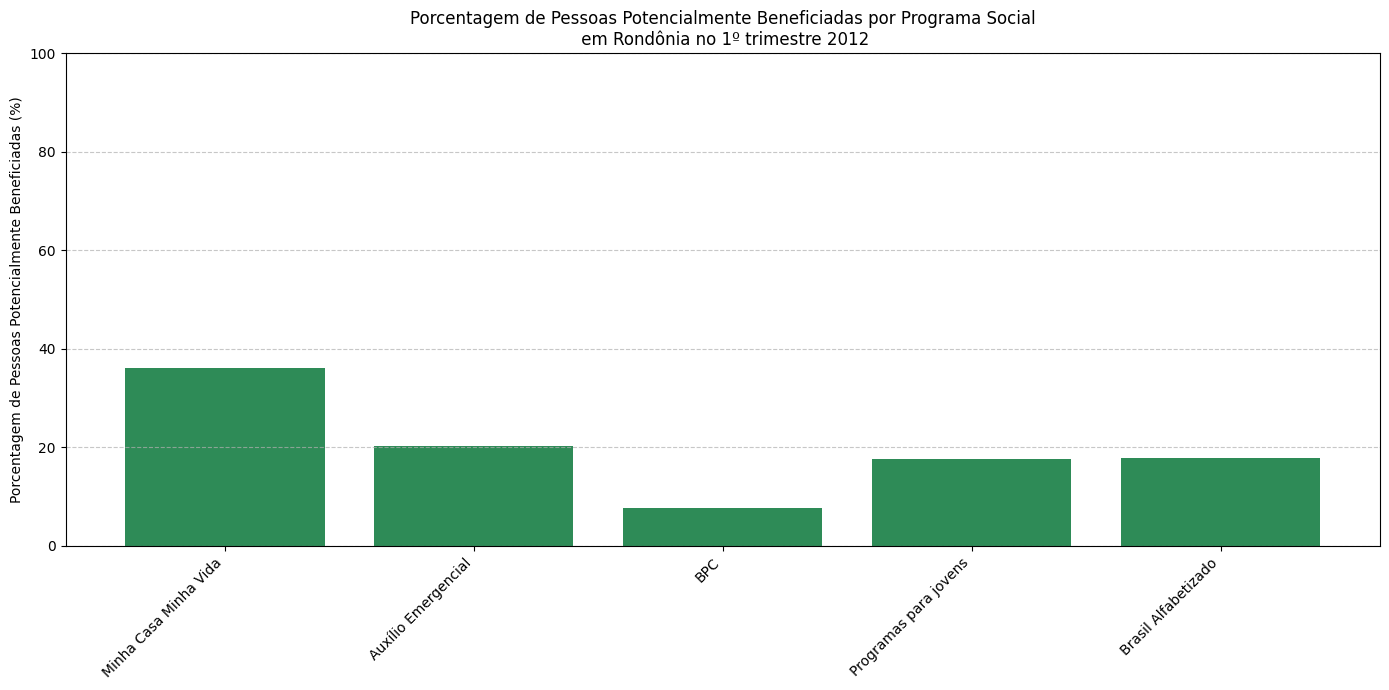


Recomendação Baseada em Popularidade:
- Programa Mais Popular (Baseline): Minha Casa Minha Vida (Popularidade Média em Todos os Dados: 30.97%)


In [18]:
import random
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt

# Assumindo que df_3_juncoes e df_4_juncoes já foram carregados e processados
# E que a função recomendar_programas_com_porcentagem (corrigida) está definida

# --- Funções para Baseline de Popularidade ---

def get_all_possible_programs():
    """Retorna uma lista de todos os programas sociais potenciais que a função de recomendação considera."""
    # Esta lista deve corresponder às chaves usadas no dicionário 'porcentagens' na função de recomendação
    return [
        "Minha Casa Minha Vida",
        "Auxílio Emergencial",
        "BPC",
        "Programas para jovens",
        "Brasil Alfabetizado",
        "Qualifica Mais"
    ]


def calculate_program_popularity(df_3_juncoes, df_4_juncoes):
    """Calcula a porcentagem média de potenciais beneficiários para cada programa em todos os dados."""
    program_total_beneficiaries = defaultdict(float)
    program_total_population = defaultdict(float)
    program_count = defaultdict(int) # Contador para o número de combinações válidas por programa

    # Vamos iterar sobre cada combinação única de município e trimestre nos dados
    # para calcular as porcentagens como na função de recomendação, mas acumulando

    # Obter todas as combinações únicas de município e trimestre
    combinacoes_unicas_3 = df_3_juncoes[['municipio', 'trimestre']].drop_duplicates()
    combinacoes_unicas_4 = df_4_juncoes[['municipio', 'trimestre']].drop_duplicates()

    # Combinar as combinações únicas de ambos os dataframes
    todas_combinacoes = pd.concat([combinacoes_unicas_3, combinacoes_unicas_4]).drop_duplicates().values.tolist()

    for municipio, trimestre in todas_combinacoes:
        # Obter os dados filtrados para o município e trimestre, similar à função de recomendação
        dados_municipio_3 = df_3_juncoes[(df_3_juncoes["municipio"] == municipio) & (df_3_juncoes["trimestre"] == trimestre)].copy()
        dados_municipio_4 = df_4_juncoes[(df_4_juncoes["municipio"] == municipio) & (df_4_juncoes["trimestre"] == trimestre)].copy()

        if dados_municipio_3.empty and dados_municipio_4.empty:
            continue # Pula se não houver dados para essa combinação

        total_pessoas = dados_municipio_4["quantidade de idade"].sum()

        if total_pessoas == 0:
            continue # Pula se a população for zero

        # Calcule os beneficiários para cada programa (lógica similar à função de recomendação)
        # Minha Casa Minha Vida
        if "grupo_etario" in dados_municipio_4.columns:
            beneficiarios_mcmv = dados_municipio_4.loc[dados_municipio_4["grupo_etario"] == "25 a 39 anos", "quantidade de idade"].sum()
            if beneficiarios_mcmv > 0:
                 program_total_beneficiaries["Minha Casa Minha Vida"] += beneficiarios_mcmv
                 program_total_population["Minha Casa Minha Vida"] += total_pessoas
                 program_count["Minha Casa Minha Vida"] += 1

        # Auxílio Emergencial
        if "grupo_etario" in dados_municipio_4.columns and "Condição de ocupação" in dados_municipio_4.columns:
            condicao_idade = dados_municipio_4["grupo_etario"].isin(["18 a 24 anos", "25 a 39 anos", "40 a 59 anos"])
            condicao_ocupacao = dados_municipio_4["Condição de ocupação"].str.contains("Fora da força de trabalho", na=False)
            beneficiarios_emergencial_df = dados_municipio_4.loc[condicao_idade & condicao_ocupacao]
            beneficiarios_emergencial = beneficiarios_emergencial_df["quantidade de idade"].sum()
            if beneficiarios_emergencial > 0:
                program_total_beneficiaries["Auxílio Emergencial"] += beneficiarios_emergencial
                program_total_population["Auxílio Emergencial"] += total_pessoas
                program_count["Auxílio Emergencial"] += 1

        # BPC
        if "grupo_etario" in dados_municipio_4.columns or "Condição de ocupação" in dados_municipio_4.columns:
            beneficiarios_idosos = 0
            if "grupo_etario" in dados_municipio_4.columns:
                beneficiarios_idosos = dados_municipio_4.loc[dados_municipio_4["grupo_etario"] == "60 anos ou mais", "quantidade de idade"].sum()

            beneficiarios_deficiencia = 0
            if "Condição de ocupação" in dados_municipio_4.columns:
                 if 'quantidade de condição de ocupação' in dados_municipio_4.columns:
                      beneficiarios_deficiencia = dados_municipio_4.loc[dados_municipio_4["Condição de ocupação"].str.contains("Pessoas com deficiência", na=False), 'quantidade de condição de ocupação'].sum()
                 else:
                      beneficiarios_deficiencia = dados_municipio_4.loc[dados_municipio_4["Condição de ocupação"].str.contains("Pessoas com deficiência", na=False), 'quantidade de idade'].sum()


            total_beneficiarios_bpc = beneficiarios_idosos + beneficiarios_deficiencia
            if total_beneficiarios_bpc > 0:
                program_total_beneficiaries["BPC"] += total_beneficiarios_bpc
                program_total_population["BPC"] += total_pessoas
                program_count["BPC"] += 1


        # Programas para jovens
        if "grupo_etario" in dados_municipio_4.columns:
            beneficiarios_jovens = dados_municipio_4.loc[dados_municipio_4["grupo_etario"] == "18 a 24 anos", "quantidade de idade"].sum()
            if beneficiarios_jovens > 0:
                program_total_beneficiaries["Programas para jovens"] += beneficiarios_jovens
                program_total_population["Programas para jovens"] += total_pessoas
                program_count["Programas para jovens"] += 1

        # Brasil Alfabetizado
        if "nivel_instrucao" in dados_municipio_4.columns:
            beneficiarios_alfabetizacao = dados_municipio_4.loc[dados_municipio_4["nivel_instrucao"] == "Ensino fundamental incompleto ou equivalente", "quantidade_escolaridade"].sum()
            if beneficiarios_alfabetizacao > 0:
                program_total_beneficiaries["Brasil Alfabetizado"] += beneficiarios_alfabetizacao
                program_total_population["Brasil Alfabetizado"] += total_pessoas
                program_count["Brasil Alfabetizado"] += 1


    program_popularity = {}
    for programa in get_all_possible_programs():
        # Calcula a média dividindo pelo total da população considerada para aquele programa
        if program_total_population[programa] > 0:
             program_popularity[programa] = (program_total_beneficiaries[programa] / program_total_population[programa]) * 100
        else:
             program_popularity[programa] = 0.0 # Define 0% se não houver população relevante considerada

    return program_popularity


def popularity_based_recommendation(program_popularity):
    """Recomenda o programa com a maior popularidade (maior porcentagem média)."""
    if not program_popularity:
        return None # Retorna None se não houver popularidade calculada

    # Encontra o programa com a maior porcentagem
    # Trata o caso em que o dicionário de popularidade está vazio
    if not program_popularity:
        return None
    most_popular_program = max(program_popularity, key=program_popularity.get)
    return most_popular_program

# --- Comparação Conceitual com Baseline de Popularidade ---

print("\n--- Comparação Conceitual com Baseline de Popularidade ---")

# Calcule a popularidade dos programas (você só precisa fazer isso uma vez após carregar os dados)
# Verifique se df_3_juncoes e df_4_juncoes não estão vazios antes de calcular a popularidade
if not df_3_juncoes.empty or not df_4_juncoes.empty:
    print("Calculando popularidade dos programas em todos os dados...")
    program_popularity = calculate_program_popularity(df_3_juncoes, df_4_juncoes)
    print("Popularidade dos programas calculada.")
    print("Popularidade (Porcentagem Média de Beneficiários Potenciais):")
    # Ordena a popularidade para exibição
    for programa, porcentagem in sorted(program_popularity.items(), key=lambda item: item[1], reverse=True):
        print(f"- {programa}: {porcentagem:.2f}%")

    # Exemplo de como gerar recomendações com a baseline para um município/trimestre específico
    # Use um município e trimestre que você sabe que existem nos seus dados
    # Verifique se há municípios e trimestres disponíveis nos DataFrames
    if not df_3_juncoes.empty:
        municipios_disponiveis = df_3_juncoes["municipio"].unique()
        trimestres_disponiveis = df_3_juncoes["trimestre"].unique()

        if len(municipios_disponiveis) > 0 and len(trimestres_disponiveis) > 0:
            municipio_exemplo = municipios_disponiveis[0] # Pega o primeiro município disponível
            trimestre_exemplo = trimestres_disponiveis[0] # Pega o primeiro trimestre disponível

            print(f"\nGerando recomendações para {municipio_exemplo} no {trimestre_exemplo} para comparação:")

            # Recomendação do Seu Sistema
            print("\nRecomendação do Seu Sistema:")
            # Chame a função do seu sistema de recomendação para ver o output e o gráfico
            # Certifique-se de que a função recomendar_programas_com_porcentagem está definida acima
            recomendar_programas_com_porcentagem(municipio_exemplo, trimestre_exemplo, df_3_juncoes, df_4_juncoes)

            # Recomendação Baseada em Popularidade
            print("\nRecomendação Baseada em Popularidade:")
            popular_rec = popularity_based_recommendation(program_popularity)
            if popular_rec:
                print(f"- Programa Mais Popular (Baseline): {popular_rec} (Popularidade Média em Todos os Dados: {program_popularity.get(popular_rec, 0.0):.2f}%)")
            else:
                print("Não foi possível gerar recomendação baseada em popularidade (sem dados de popularidade).")

        else:
            print("\nNão há municípios ou trimestres suficientes nos dados para realizar a comparação de exemplo.")
    else:
         print("\nDataFrames de dados estão vazios. Não é possível calcular popularidade ou fazer comparações.")


else:
    print("\nDataFrames df_3_juncoes e df_4_juncoes estão vazios. Não é possível calcular popularidade ou fazer comparações com baselines.")


